X_frames_reg: (17280, 5, 6) (N_times, 5, n_features)
y_frames_reg: (17280,)
X_seq_reg: (17276, 5, 5, 6) (N_samples, 5, 5, n_features)
y_seq_reg: (17276,)
X_lstm_reg: (17276, 5, 30) (N_samples, seq_len, input_dim)
input_dim_reg: 30
Train: (13820, 5, 30) (13820,) | Val: (3456, 5, 30) (3456,)
Epoch 01/12 | train_loss=2177.0644 | val_loss=2288.1615
Epoch 02/12 | train_loss=946.4511 | val_loss=1322.8353
Epoch 03/12 | train_loss=474.3700 | val_loss=837.6958
Epoch 04/12 | train_loss=275.9809 | val_loss=592.8287
Epoch 05/12 | train_loss=203.1675 | val_loss=471.8142
Epoch 06/12 | train_loss=178.5055 | val_loss=413.1847
Epoch 07/12 | train_loss=174.9179 | val_loss=385.1157
Epoch 08/12 | train_loss=153.9013 | val_loss=330.2236
Epoch 09/12 | train_loss=108.6712 | val_loss=255.9019
Epoch 10/12 | train_loss=82.8138 | val_loss=198.8433
Epoch 11/12 | train_loss=65.4892 | val_loss=155.6087
Epoch 12/12 | train_loss=54.9805 | val_loss=122.9929

=== Validation Regression Metrics ===
{'MSE': 122.992928, 'M

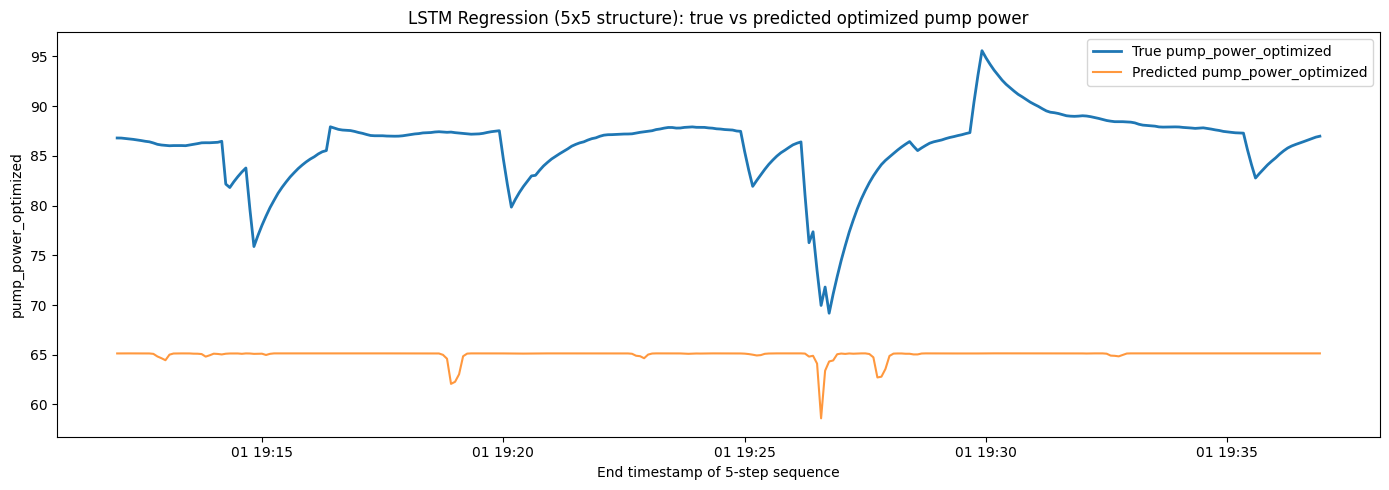

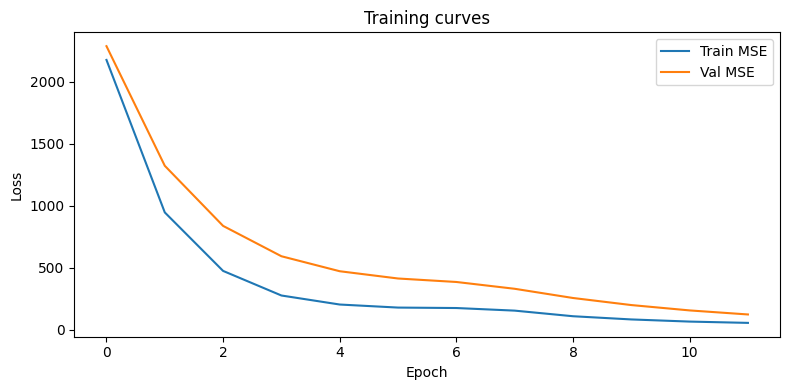

In [1]:
# 5x5 LSTM Regression: predict pump_power_optimized
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================
# Config
# =====================================================
CSV_PATH_REG = "smart_water_minimal_physics_with_sensor_id.csv"
FEATURE_COLS_REG = ["pressure", "flow_rate", "temperature", "pump_power", "pressure_mean", "pressure_var"]
TARGET_COL_REG = "pump_power_optimized"
SENSOR_IDS_REG = [1, 2, 3, 4, 5]
SEQ_LEN_REG = 5
BATCH_SIZE_REG = 64
EPOCHS_REG = 12
LR_REG = 1e-3
DEVICE_REG = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_STATE_REG = 42

np.random.seed(RANDOM_STATE_REG)
torch.manual_seed(RANDOM_STATE_REG)

# =====================================================
# 1) Load + preprocess
# =====================================================
df_reg = pd.read_csv(CSV_PATH_REG)

required_cols_reg = ["timestamp", "sensor_id", *FEATURE_COLS_REG, TARGET_COL_REG]
missing_reg = [c for c in required_cols_reg if c not in df_reg.columns]
if missing_reg:
    raise ValueError(f"Missing required columns: {missing_reg}")

df_reg["timestamp"] = pd.to_datetime(df_reg["timestamp"], errors="coerce")
df_reg = df_reg.dropna(subset=["timestamp"]).copy()
df_reg = df_reg.sort_values(["timestamp", "sensor_id"]).reset_index(drop=True)

for col in FEATURE_COLS_REG + [TARGET_COL_REG]:
    df_reg[col] = pd.to_numeric(df_reg[col], errors="coerce")
    df_reg[col] = df_reg.groupby("sensor_id")[col].transform(lambda s: s.ffill().bfill())
    df_reg[col] = df_reg[col].fillna(df_reg[col].median())

# Verify exactly 5 sensors per timestamp
counts_reg = df_reg.groupby("timestamp")["sensor_id"].nunique()
bad_counts_reg = counts_reg[counts_reg != len(SENSOR_IDS_REG)]
if len(bad_counts_reg) > 0:
    raise ValueError(
        f"Found {len(bad_counts_reg)} timestamps without exactly {len(SENSOR_IDS_REG)} sensors. Example: {bad_counts_reg.head().to_dict()}"
    )

# Verify sensor ids are exactly 1..5 per timestamp
sensor_sets_ok_reg = df_reg.groupby("timestamp")["sensor_id"].apply(
    lambda s: set(s.tolist()) == set(SENSOR_IDS_REG)
    )
if not sensor_sets_ok_reg.all():
    bad_ts = sensor_sets_ok_reg[~sensor_sets_ok_reg].index[:5].tolist()
    raise ValueError(f"Some timestamps do not contain sensor ids {SENSOR_IDS_REG}. Examples: {bad_ts}")

# =====================================================
# 2) Build timestamp frames: (5 sensors, n_features)
#    and one target per timestamp
# =====================================================
grp_reg = df_reg.groupby("timestamp", sort=True)
N_times_reg = grp_reg.ngroups
n_features_reg = len(FEATURE_COLS_REG)

X_frames_reg = np.zeros((N_times_reg, len(SENSOR_IDS_REG), n_features_reg), dtype=np.float32)
y_frames_reg = np.zeros(N_times_reg, dtype=np.float32)
frame_times_reg = []

for i, (ts, g) in enumerate(grp_reg):
    # Fixed sensor order at each timestamp
    g = g.set_index("sensor_id").loc[SENSOR_IDS_REG].reset_index()

    # one frame = 5 sensors x n_features
    X_frames_reg[i] = g[FEATURE_COLS_REG].values.astype(np.float32)

    # target per timestamp (mean across sensors; same if identical values)
    y_frames_reg[i] = float(g[TARGET_COL_REG].mean())
    frame_times_reg.append(ts)

frame_times_reg = np.array(frame_times_reg)
print("X_frames_reg:", X_frames_reg.shape, "(N_times, 5, n_features)")
print("y_frames_reg:", y_frames_reg.shape)

# Standardize features using train-time frames only
split_time_idx = int(0.8 * N_times_reg)
scaler_reg = StandardScaler()
scaler_reg.fit(X_frames_reg[:split_time_idx].reshape(-1, n_features_reg))
X_frames_reg_scaled = scaler_reg.transform(X_frames_reg.reshape(-1, n_features_reg)).reshape(X_frames_reg.shape).astype(np.float32)

# =====================================================
# 3) Build 5x5 sequences
#    X_seq: (N_samples, 5, 5, n_features)
#    y_seq: target at last timestamp
# =====================================================
X_seq_reg, y_seq_reg, t_seq_reg = [], [], []
for i in range(0, N_times_reg - SEQ_LEN_REG + 1):
    # 5 consecutive timestamps, each with 5 sensors
    seq_4d = X_frames_reg_scaled[i:i + SEQ_LEN_REG]  # (5,5,n_features)
    target = y_frames_reg[i + SEQ_LEN_REG - 1]
    t_last = frame_times_reg[i + SEQ_LEN_REG - 1]

    X_seq_reg.append(seq_4d)
    y_seq_reg.append(target)
    t_seq_reg.append(t_last)

X_seq_reg = np.array(X_seq_reg, dtype=np.float32)
y_seq_reg = np.array(y_seq_reg, dtype=np.float32)
t_seq_reg = np.array(t_seq_reg)

print("X_seq_reg:", X_seq_reg.shape, "(N_samples, 5, 5, n_features)")
print("y_seq_reg:", y_seq_reg.shape)

# Reshape for LSTM: (batch, seq_len, input_dim=5*n_features)
input_dim_reg = len(SENSOR_IDS_REG) * n_features_reg
X_lstm_reg = X_seq_reg.reshape(len(X_seq_reg), SEQ_LEN_REG, input_dim_reg)
y_lstm_reg = y_seq_reg.copy()

print("X_lstm_reg:", X_lstm_reg.shape, "(N_samples, seq_len, input_dim)")
print("input_dim_reg:", input_dim_reg)

# =====================================================
# 4) Time-respecting train/val split
# =====================================================
N_samples_reg = len(X_lstm_reg)
split_seq_idx = int(0.8 * N_samples_reg)

X_train_reg = X_lstm_reg[:split_seq_idx]
y_train_reg = y_lstm_reg[:split_seq_idx]
X_val_reg = X_lstm_reg[split_seq_idx:]
y_val_reg = y_lstm_reg[split_seq_idx:]
t_val_reg = t_seq_reg[split_seq_idx:]

print("Train:", X_train_reg.shape, y_train_reg.shape, "| Val:", X_val_reg.shape, y_val_reg.shape)

class SeqRegDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_reg = DataLoader(SeqRegDataset(X_train_reg, y_train_reg), batch_size=BATCH_SIZE_REG, shuffle=False)
val_loader_reg = DataLoader(SeqRegDataset(X_val_reg, y_val_reg), batch_size=BATCH_SIZE_REG, shuffle=False)

# =====================================================
# 5) LSTM regression model
# =====================================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_h = out[:, -1, :]
        y_hat = self.fc(self.dropout(last_h)).squeeze(1)
        return y_hat

model_reg = LSTMRegressor(input_dim=input_dim_reg, hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE_REG)
criterion_reg = nn.MSELoss()
optimizer_reg = torch.optim.Adam(model_reg.parameters(), lr=LR_REG)

# =====================================================
# 6) Train + validation loss tracking
# =====================================================
train_losses_reg, val_losses_reg = [], []

def predict_reg(model, loader):
    model.eval()
    ys, yhats = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE_REG)
            pred = model(xb).cpu().numpy()
            ys.append(yb.numpy())
            yhats.append(pred)
    return np.concatenate(ys), np.concatenate(yhats)

for epoch in range(1, EPOCHS_REG + 1):
    model_reg.train()
    running_train_loss = 0.0

    for xb, yb in train_loader_reg:
        xb, yb = xb.to(DEVICE_REG), yb.to(DEVICE_REG)
        optimizer_reg.zero_grad()
        pred = model_reg(xb)
        loss = criterion_reg(pred, yb)
        loss.backward()
        optimizer_reg.step()
        running_train_loss += loss.item() * len(xb)

    train_loss = running_train_loss / len(train_loader_reg.dataset)
    train_losses_reg.append(train_loss)

    # Validation loss
    model_reg.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_reg:
            xb, yb = xb.to(DEVICE_REG), yb.to(DEVICE_REG)
            pred = model_reg(xb)
            vloss = criterion_reg(pred, yb)
            running_val_loss += vloss.item() * len(xb)
    val_loss = running_val_loss / len(val_loader_reg.dataset)
    val_losses_reg.append(val_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS_REG} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# =====================================================
# 7) Evaluation metrics (MSE, MAE, R2)
# =====================================================
y_val_true_reg, y_val_pred_reg = predict_reg(model_reg, val_loader_reg)

mse_reg = mean_squared_error(y_val_true_reg, y_val_pred_reg)
mae_reg = mean_absolute_error(y_val_true_reg, y_val_pred_reg)
r2_reg = r2_score(y_val_true_reg, y_val_pred_reg)

print("\n=== Validation Regression Metrics ===")
print({"MSE": round(mse_reg, 6), "MAE": round(mae_reg, 6), "R2": round(r2_reg, 6)})

# =====================================================
# 8) Plot true vs predicted over time (validation slice)
# =====================================================
plot_n_reg = min(300, len(y_val_true_reg))
plot_df_reg = pd.DataFrame({
    "end_timestamp": pd.to_datetime(t_val_reg[:plot_n_reg]),
    "y_true": y_val_true_reg[:plot_n_reg],
    "y_pred": y_val_pred_reg[:plot_n_reg],
})

plt.figure(figsize=(14, 5))
plt.plot(plot_df_reg["end_timestamp"], plot_df_reg["y_true"], label="True pump_power_optimized", linewidth=2)
plt.plot(plot_df_reg["end_timestamp"], plot_df_reg["y_pred"], label="Predicted pump_power_optimized", alpha=0.8)
plt.title("LSTM Regression (5x5 structure): true vs predicted optimized pump power")
plt.xlabel("End timestamp of 5-step sequence")
plt.ylabel("pump_power_optimized")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Optional: training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses_reg, label="Train MSE")
plt.plot(val_losses_reg, label="Val MSE")
plt.title("Training curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Epoch 01/50 | train_loss=0.0605 | val_loss=2.4750
Epoch 02/50 | train_loss=0.1706 | val_loss=0.4448
Epoch 03/50 | train_loss=0.1000 | val_loss=0.6331
Epoch 04/50 | train_loss=0.1380 | val_loss=0.1987
Epoch 05/50 | train_loss=0.1072 | val_loss=0.1271
Epoch 06/50 | train_loss=0.1139 | val_loss=0.1514
Epoch 07/50 | train_loss=0.1785 | val_loss=0.1943
Epoch 08/50 | train_loss=0.1242 | val_loss=0.2034
Epoch 09/50 | train_loss=0.0769 | val_loss=0.2193
Epoch 10/50 | train_loss=0.0576 | val_loss=0.2043
Epoch 11/50 | train_loss=0.0514 | val_loss=0.1409
Epoch 12/50 | train_loss=0.0477 | val_loss=0.1484
Epoch 13/50 | train_loss=0.0448 | val_loss=0.1261
Epoch 14/50 | train_loss=0.0435 | val_loss=0.1480
Epoch 15/50 | train_loss=0.0453 | val_loss=0.1185
Epoch 16/50 | train_loss=0.0526 | val_loss=0.0689
Epoch 17/50 | train_loss=0.0668 | val_loss=0.0782
Epoch 18/50 | train_loss=0.0678 | val_loss=0.1404
Epoch 19/50 | train_loss=0.0504 | val_loss=0.2765
Epoch 20/50 | train_loss=0.0423 | val_loss=0.2182


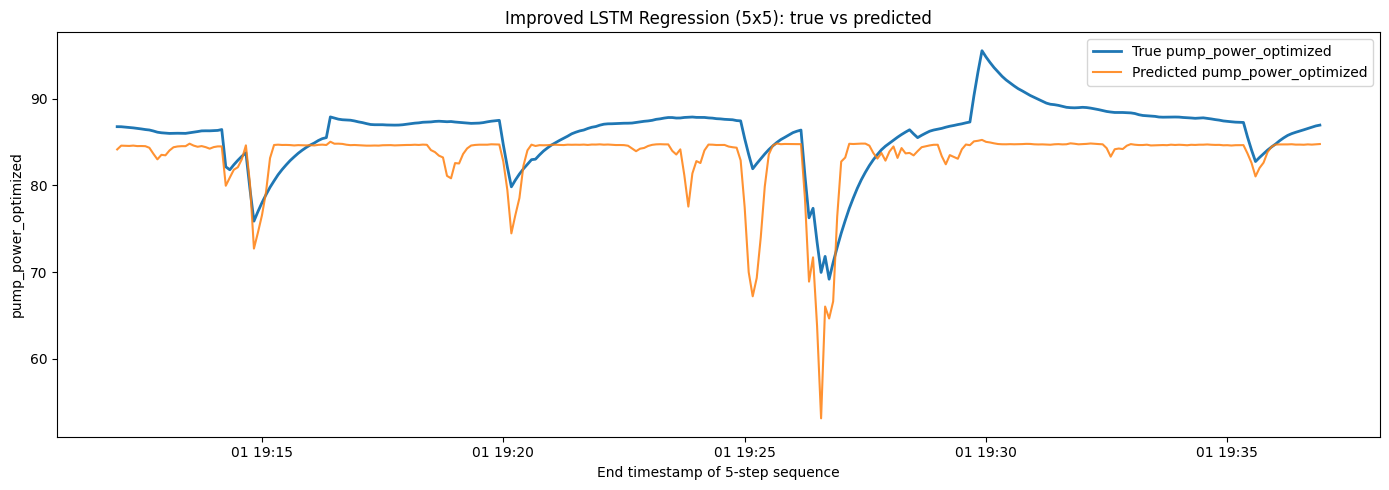

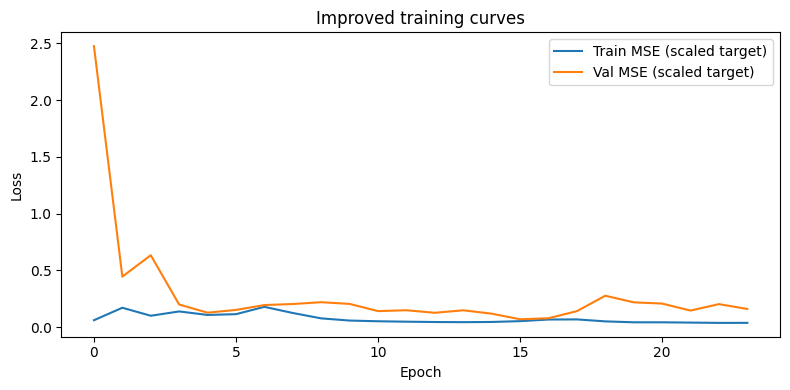

In [2]:
# Improved 5x5 LSTM Regression: target scaling + larger model + early stopping
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------
# Config (improved)
# -------------------------
SEQ_LEN_REG2 = 5
BATCH_SIZE_REG2 = 64
EPOCHS_REG2 = 50
PATIENCE_REG2 = 8
MIN_DELTA_REG2 = 1e-4
LR_REG2 = 1e-3
DEVICE_REG2 = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse already prepared frame-level arrays from Cell 17
X_seq_reg2 = X_seq_reg.copy()        # (N_samples, 5, 5, n_features)
y_seq_reg2 = y_seq_reg.copy()        # (N_samples,)
t_seq_reg2 = t_seq_reg.copy()

# Reshape to LSTM input: (batch, seq_len, input_dim=5*n_features)
input_dim_reg2 = X_seq_reg2.shape[2] * X_seq_reg2.shape[3]
X_lstm_reg2 = X_seq_reg2.reshape(len(X_seq_reg2), SEQ_LEN_REG2, input_dim_reg2).astype(np.float32)

# Time split (first 80% train, last 20% val)
split_idx_reg2 = int(0.8 * len(X_lstm_reg2))
X_train_reg2, X_val_reg2 = X_lstm_reg2[:split_idx_reg2], X_lstm_reg2[split_idx_reg2:]
y_train_reg2, y_val_reg2 = y_seq_reg2[:split_idx_reg2], y_seq_reg2[split_idx_reg2:]
t_val_reg2 = t_seq_reg2[split_idx_reg2:]

# Target scaling (fit on train targets only)
y_scaler_reg2 = StandardScaler()
y_train_reg2_scaled = y_scaler_reg2.fit_transform(y_train_reg2.reshape(-1, 1)).reshape(-1).astype(np.float32)
y_val_reg2_scaled = y_scaler_reg2.transform(y_val_reg2.reshape(-1, 1)).reshape(-1).astype(np.float32)

class SeqRegDataset2(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader_reg2 = DataLoader(SeqRegDataset2(X_train_reg2, y_train_reg2_scaled), batch_size=BATCH_SIZE_REG2, shuffle=False)
val_loader_reg2 = DataLoader(SeqRegDataset2(X_val_reg2, y_val_reg2_scaled), batch_size=BATCH_SIZE_REG2, shuffle=False)

class LSTMRegressor2(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_h = out[:, -1, :]
        return self.fc(self.dropout(last_h)).squeeze(1)

model_reg2 = LSTMRegressor2(input_dim=input_dim_reg2, hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE_REG2)
criterion_reg2 = nn.MSELoss()
optimizer_reg2 = torch.optim.Adam(model_reg2.parameters(), lr=LR_REG2)

best_val_loss_reg2 = np.inf
best_state_reg2 = None
best_epoch_reg2 = 0
wait_reg2 = 0

train_losses_reg2, val_losses_reg2 = [], []

for epoch in range(1, EPOCHS_REG2 + 1):
    model_reg2.train()
    run_train = 0.0
    for xb, yb in train_loader_reg2:
        xb, yb = xb.to(DEVICE_REG2), yb.to(DEVICE_REG2)
        optimizer_reg2.zero_grad()
        pred = model_reg2(xb)
        loss = criterion_reg2(pred, yb)
        loss.backward()
        optimizer_reg2.step()
        run_train += loss.item() * len(xb)
    train_loss = run_train / len(train_loader_reg2.dataset)

    model_reg2.eval()
    run_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_reg2:
            xb, yb = xb.to(DEVICE_REG2), yb.to(DEVICE_REG2)
            pred = model_reg2(xb)
            vloss = criterion_reg2(pred, yb)
            run_val += vloss.item() * len(xb)
    val_loss = run_val / len(val_loader_reg2.dataset)

    train_losses_reg2.append(train_loss)
    val_losses_reg2.append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS_REG2} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < (best_val_loss_reg2 - MIN_DELTA_REG2):
        best_val_loss_reg2 = val_loss
        best_state_reg2 = copy.deepcopy(model_reg2.state_dict())
        best_epoch_reg2 = epoch
        wait_reg2 = 0
    else:
        wait_reg2 += 1
        if wait_reg2 >= PATIENCE_REG2:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch_reg2} (val_loss={best_val_loss_reg2:.4f})")
            break

if best_state_reg2 is not None:
    model_reg2.load_state_dict(best_state_reg2)

# Predict (scaled), then inverse-transform to original units
model_reg2.eval()
val_preds_scaled = []
with torch.no_grad():
    for xb, _ in val_loader_reg2:
        xb = xb.to(DEVICE_REG2)
        val_preds_scaled.append(model_reg2(xb).cpu().numpy())
y_val_pred_scaled_reg2 = np.concatenate(val_preds_scaled)

y_val_pred_reg2 = y_scaler_reg2.inverse_transform(y_val_pred_scaled_reg2.reshape(-1, 1)).reshape(-1)
y_val_true_reg2 = y_val_reg2.copy()

mse_reg2 = mean_squared_error(y_val_true_reg2, y_val_pred_reg2)
mae_reg2 = mean_absolute_error(y_val_true_reg2, y_val_pred_reg2)
r2_reg2 = r2_score(y_val_true_reg2, y_val_pred_reg2)

print("\n=== Improved Validation Regression Metrics ===")
print(f"Best epoch: {best_epoch_reg2}")
print({"MSE": round(mse_reg2, 6), "MAE": round(mae_reg2, 6), "R2": round(r2_reg2, 6)})

# Plot true vs predicted on a validation slice
plot_n_reg2 = min(300, len(y_val_true_reg2))
plot_df_reg2 = pd.DataFrame({
    "end_timestamp": pd.to_datetime(t_val_reg2[:plot_n_reg2]),
    "y_true": y_val_true_reg2[:plot_n_reg2],
    "y_pred": y_val_pred_reg2[:plot_n_reg2],
})

plt.figure(figsize=(14, 5))
plt.plot(plot_df_reg2["end_timestamp"], plot_df_reg2["y_true"], label="True pump_power_optimized", linewidth=2)
plt.plot(plot_df_reg2["end_timestamp"], plot_df_reg2["y_pred"], label="Predicted pump_power_optimized", alpha=0.85)
plt.title("Improved LSTM Regression (5x5): true vs predicted")
plt.xlabel("End timestamp of 5-step sequence")
plt.ylabel("pump_power_optimized")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_losses_reg2, label="Train MSE (scaled target)")
plt.plot(val_losses_reg2, label="Val MSE (scaled target)")
plt.title("Improved training curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()